# Where does the J-space change across layers?

**Question:** Can we reproduce the layer-structure graphs in [section 4.1](https://transformer-circuits.pub/2026/workspace/index.html#struct-layers) for an arbitrary supported causal language model?

**Answer:** This notebook computes the **Figure 27 CKA heatmap with a logit-lens control** and **Figure 28 four-panel diagnostic** from a selected model and its Jacobian lens. The saved outputs are an executed **tiny, untrained CPU demo** that validates the pipeline; they are not evidence for a workspace in a trained model. Set `RUN_MODE = "hf"`, choose `MODEL_ID`, and run: real-model mode now downloads a matching **prefitted HuggingFace lens** by default. Set `LENS_SOURCE = "fit"` only when you explicitly want a new fit.

The workflow reuses `model_agnostic_lens_dataset.ipynb`: `jlens.from_hf`, shared `ActivationRecorder` block outputs, `DatasetFitRun`, `load_fit_prompts`, and `fit_with_progress`. Reusable measurements live in `jlens/workspace_layers.py`. No GPT-2-specific internals are required. The model's curves need not resemble Sonnet's, and no workspace boundaries are imposed.

[Open in Colab](https://colab.research.google.com/github/ai360-project-school-j-lens/jacobian-lens-gpt2/blob/main/notebooks/model_agnostic/workspace_layers.ipynb)

Run all cells in order, locally or in a fresh Colab runtime. Setup finds a checkout or clones this fork and automatically installs its dependencies on Colab. Locally, use `uv sync --extra dev` or set `INSTALL_DEPENDENCIES=True` in setup. The default demo downloads no model weights or lens; fresh Colab setup still downloads the repository and dependencies.

For the real experiment on Colab, select a GPU runtime, set `RUN_MODE="hf"`, and leave `LENS_SOURCE="hub"`. Qwen3-1.7B is the default; larger presets require correspondingly more GPU memory. Gated models such as Gemma require HuggingFace access and authentication before model loading. If installing upgrades in an already-used kernel, restart it before continuing.

Evaluation already batches length-sorted prompts: one model forward per batch, with shared layer activations and chunked vocabulary readouts. `BATCH_SIZE` controls model batches; `POSITION_CHUNK_SIZE` controls readout memory. Reduce either if the corresponding stage runs out of memory. Colab local files disappear when its runtime is replaced: set `CACHE_ROOT` to an already-mounted Drive directory to preserve fits and results; the HuggingFace download cache is separate.

## Measurement definitions

The reference heatmap compares J-lens vector geometry across layers. Its companion panels show next-token agreement, logit kurtosis, positional persistence, and dimensionality. Curve settings below match the site's [Figure 28 data](https://transformer-circuits.pub/2026/workspace/data/layer-lines/main.json).

Our implementation makes the following estimator choices explicit:

- **Geometry:** use raw linear-head vectors `X_l = W_U @ J_l`, centered over the full vocabulary. Compute linear CKA between their Gram matrices. Final-normalization gains, biases and logit softcaps are excluded from geometry; actual readouts include all model readout transforms. No row normalization or vocabulary sampling is used.
- **Accuracy:** fraction of valid positions where the model's final top-1 token is in the layer's top-k. This is agreement with the model, not ground-truth corpus-token accuracy. Ties break by ascending token ID.
- **Kurtosis:** `mean((z - mean(z))**4) / var(z)**2 - 3` across vocabulary logits at each position. Plot position percentiles, not a single average. Constant distributions are undefined; the table reports coverage.
- **Autocorrelation:** compare top-1 token equality at original positions `t` and `t + lag` within each text. Use the exact expected repeat rate under uniform shuffling of valid positions within that text; pool counts across texts, then plot `log((observed_matches + 0.5) / (expected_matches + 0.5))`. This deterministic null and smoothing convention are our choices; the paper does not fully specify them. Missing pairs give NaN.
- **Dimensions:** the minimum number of principal components explaining each requested fraction of centered vector variance, divided by residual width. Squared singular values define variance.

Block outputs are indexed from zero: the first block is displayed at 0 and the final block at 100. This is a normalized depth convention, not an embedding-layer measurement. Select at most 25 roughly evenly spaced blocks. Padding and special input tokens are excluded; all other positions, including the last real token, are eligible. Lags retain gaps from excluded tokens.

The default held-out data are the repository's task prompts. This differs from the paper's corpus. For a representative study, use your own independent evaluation corpus through `EVAL_JSONL`, increase the fit sample, and compare results across seeds. The ambiguous-input intervention later in section 4.1 is a separate experiment and is not implemented here.

In [1]:
import hashlib
import importlib.metadata
import json
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/ai360-project-school-j-lens/jacobian-lens-gpt2.git"
INSTALL_DEPENDENCIES = "COLAB_RELEASE_TAG" in os.environ or "google.colab" in sys.modules
REPO_DIR = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "jlens" / "evaluation.py").is_file()), None,
)
if REPO_DIR is None:
    REPO_DIR = Path.cwd() / "jacobian-lens-gpt2"
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
REPO_DIR = REPO_DIR.resolve()
required_files = ("jlens/evaluation.py", "jlens/workspace_layers.py",
                  "jlens/workspace_plotting.py")
if any(not (REPO_DIR / name).is_file() for name in required_files):
    raise RuntimeError(
        f"Checkout at {REPO_DIR} lacks workspace evaluation code. "
        f"Update it with: git -C {REPO_DIR} pull --ff-only"
    )
if INSTALL_DEPENDENCIES:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-e", str(REPO_DIR)],
        check=True,
    )
# Colab may preload Matplotlib. Pip can replace files while old classes remain
# in memory; a newly imported SVG backend then sees an incompatible Text API.
loaded_matplotlib = sys.modules.get("matplotlib")
if loaded_matplotlib is not None:
    installed_version = importlib.metadata.version("matplotlib")
    loaded_version = getattr(loaded_matplotlib, "__version__", None)
    if loaded_version != installed_version:
        raise RuntimeError(
            f"Matplotlib changed from loaded {loaded_version} to installed {installed_version}. "
            "Restart the Colab session/runtime now, then run all cells again. "
            "Cached measurements on disk are retained; no factory reset is needed."
        )
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))
print("Repository:", REPO_DIR)
print("Dependencies installed." if INSTALL_DEPENDENCIES else "Using the current Python environment.")

Repository: /home/kitlix/projects/jacobian-lens-gpt2
Using the current Python environment.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

import jlens
from jlens.artifact_provenance import download_lens_artifact
from jlens.evaluation import (
    DATASETS,
    FIT_MIX,
    fit_with_progress,
    load_eval,
    load_fit_prompts,
)
from jlens.notebook_setup import DatasetFitRun, runtime_metadata, save_json
from jlens.sharded_fitting import benchmark_dim_batches
from jlens.workspace_layers import (
    LayerGeometry,
    plot_workspace_layers,
    workspace_geometry,
    workspace_readouts,
)

%matplotlib inline

## Configuration

The saved outputs use `RUN_MODE="demo"`, an offline check. Switch to `"hf"` to load the selected model **and its prefitted lens**, following the pretrained-summary notebook. The default real model is Qwen3-1.7B, with matching presets for Qwen3-4B and Gemma-4-31B. Change `MODEL_ID` and select the corresponding entry in `HUB_LENS`, or supply another Hub repo/file pair for your model. The Gemma preset is the same artifact used by `pretrained_generated_answer_summary.ipynb`.

`LENS_SOURCE="hub"` downloads through the existing `download_lens_artifact` helper: it resolves the Hub revision to an immutable commit, verifies the published size/SHA-256, and reuses the HuggingFace cache. `LENS_SOURCE="local"` loads `EXISTING_LENS_PATH`. Neither mode downloads fitting corpora, calibrates, or fits. Errors stop the load. To fit deliberately, select `LENS_SOURCE="fit"`.

The receipt identifies the lens artifact; its original fitting/model compatibility is still external provenance. The notebook checks residual width, layer coverage, matrix shape, and finite values. Use a **final** lens, not a fit checkpoint. A custom adapter needs `LensModel` plus an explicit linear unembedding weight for geometry.

In [3]:
RUN_MODE = "demo"  # "hf" for real model measurements
MODEL_ID = "Qwen/Qwen3-1.7B"
MODEL_REVISION = None  # Pin a HuggingFace commit for repeatable model weights.
LENS_SOURCE = "hub"  # "hub", "local", or explicitly "fit"; demo always uses a tiny fit.
PREFITTED_LENSES = {
    "Qwen/Qwen3-1.7B": "qwen3-1.7b/jlens/Salesforce-wikitext/Qwen3-1.7B_jacobian_lens.pt",
    "Qwen/Qwen3-4B": "qwen3-4b/jlens/Salesforce-wikitext/Qwen3-4B_jacobian_lens.pt",
    "google/gemma-4-31B": "gemma-4-31b/jlens/Salesforce-wikitext/gemma-4-31B_jacobian_lens.pt",
}
HUB_LENS = dict(
    repo_id="neuronpedia/jacobian-lens",
    filename=PREFITTED_LENSES.get(MODEL_ID),  # Or an explicit filename for your model.
    revision="main",  # Pin the resolved commit printed in the receipt for repeat runs.
)
EXISTING_LENS_PATH = None  # LENS_SOURCE="local": Path("/path/to/matching/final/lens.pt")
EVAL_JSONL = None  # Optional JSONL file, one {"text": "...", "source": "..."} per line.

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# T4 and other older Colab GPUs use fp16; bf16 requires hardware support.
DTYPE = (
    torch.bfloat16 if DEVICE == "cuda" and torch.cuda.is_bf16_supported(including_emulation=False)
    else torch.float16 if DEVICE == "cuda" else torch.float32
)
MAX_SEQ_LEN = 128
N_PLOT_LAYERS = 25
BATCH_SIZE = 8  # Prompts per shared model forward; lower for limited GPU memory.
POSITION_CHUNK_SIZE = 32  # Reduce for large vocabularies.
GEOMETRY_DEVICE = "cpu"  # CPU/CUDA with float64 support; independent of model device.
VOCAB_CHUNK_SIZE = 4096
EVAL_ITEMS_PER_DATASET = 24
FIT_FRACTION = 0.25
FIT_SEED = 0
DIM_BATCH = None  # Measure safe candidates in HF mode; demo uses width 8.
RUN_LABEL = "workspace-layers-v1"
CACHE_ROOT = REPO_DIR / "runs" / "workspace_layers"  # gitignored; temporary on Colab
# Optional, after mounting Drive yourself:
# CACHE_ROOT = Path("/content/drive/MyDrive/jacobian-lens-runs/workspace_layers")

KS = (1, 2, 4, 8, 16, 32, 64, 128)
PERCENTILES = (1, 10, 25, 50, 75, 90, 99)
LAGS = (1, 2, 4, 8, 16, 32)
VARIANCE_THRESHOLDS = (0.9, 0.95, 0.98, 0.99, 0.995)
assert RUN_MODE in {"demo", "hf"}
assert LENS_SOURCE in {"hub", "local", "fit"}
if RUN_MODE == "hf" and LENS_SOURCE == "hub" and not HUB_LENS.get("filename"):
    raise ValueError("No preset for MODEL_ID; set HUB_LENS['filename'] to its matching lens.")
if RUN_MODE == "hf" and LENS_SOURCE == "local" and EXISTING_LENS_PATH is None:
    raise ValueError("Set EXISTING_LENS_PATH for LENS_SOURCE='local'.")

In [4]:
if RUN_MODE == "demo":
    from tests.tiny import TinyDecoder

    model = TinyDecoder(n_layers=6, seed=FIT_SEED).eval()
    unembedding_weight = model.lm_head.weight
    runtime = dict(model_id="offline/TinyDecoder", dtype="float32", device="cpu",
                   d_model=model.d_model, n_layers=model.n_layers, seed=FIT_SEED,
                   torch_version=str(torch.__version__))
    demo_fit_texts = [
        "A small decoder is useful for checking linear algebra and hooks.",
        "Independent fitting examples never include the evaluation prompts.",
        "The cache records the exact ordered fitting corpus and settings.",
        "Numerical checks compare batched results against direct calculations.",
    ]

    def fit_prompt_loader(mix, seed):
        return pd.DataFrame({"source": "synthetic-demo", "text": demo_fit_texts})
else:
    from transformers import AutoModelForCausalLM, AutoTokenizer

    hf_model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, revision=MODEL_REVISION, dtype=DTYPE,
    ).to(DEVICE).eval()
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, revision=MODEL_REVISION)
    model = jlens.from_hf(hf_model, tokenizer, compile=False)
    head = hf_model.get_output_embeddings()
    if type(head) is not torch.nn.Linear:
        raise TypeError("Geometry requires a plain linear head or an explicit W_U.")
    unembedding_weight = head.weight
    runtime = runtime_metadata(model, hf_model, MODEL_ID, DTYPE, DEVICE)
    fit_prompt_loader = load_fit_prompts

assert model.n_layers >= 2
layers = np.unique(np.linspace(0, model.n_layers - 1,
                              min(N_PLOT_LAYERS, model.n_layers)).round().astype(int)).tolist()
label = "OFFLINE DEMO — untrained TinyDecoder" if RUN_MODE == "demo" else runtime["model_id"]
print(label)
display(pd.DataFrame([runtime]))
print("Measured block indices:", layers)
print(f"Stored geometry matrices: ~{len(layers) * model.d_model**2 * 4 / 2**30:.2f} GiB, "
      "plus float64 workspaces, lens matrices, activations and model weights.")

OFFLINE DEMO — untrained TinyDecoder


,model_id,dtype,device,d_model,n_layers,seed,torch_version
0,offline/TinyDecoder,float32,cpu,8,6,0,2.12.0+cu130


Measured block indices: [0, 1, 2, 3, 4, 5]
Stored geometry matrices: ~0.00 GiB, plus float64 workspaces, lens matrices, activations and model weights.


## Load the prefitted lens (or explicitly fit)

For real models, `LENS_SOURCE="hub"` loads the selected HuggingFace artifact and records its receipt with the measurements. `"local"` reads a supplied final file. These branches never invoke `DatasetFitRun` or fitting. Final-layer readout always uses identity transport.

Only `LENS_SOURCE="fit"` (or the offline demo) uses the managed fitting configuration from the generic dataset notebook. It saves the ordered corpus and settings, excludes the first 16 positions and final position during fitting, and reuses completed fits. These settings do **not** describe a downloaded lens. Evaluation has separate position selection.

Geometry uses exact full-vocabulary covariance, avoiding a vocabulary-squared matrix. It still costs cubic work in residual width for eigendecompositions and retains approximately `4 * number_of_layers * d_model**2` bytes of Gram features, plus workspaces. Large models may need substantial CPU RAM and time.

In [5]:
# Invalidate dependent state before loading, including on download/validation failure.
fitted_lens = lens_path = lens_provenance = fit_run = None
readouts = geometry = measurement_config = None
source = "fit" if RUN_MODE == "demo" else LENS_SOURCE
if source == "hub":
    artifact = download_lens_artifact(**HUB_LENS)
    lens_path = Path(artifact.path)
    lens_provenance = {"source": "hub", **artifact.to_dict()}
    candidate_lens = jlens.JacobianLens.load(str(lens_path))
    display(lens_provenance)
    print("Loaded prefitted HuggingFace lens; no fitting or calibration.")
elif source == "local":
    lens_path = Path(EXISTING_LENS_PATH).expanduser().resolve()
    candidate_lens = jlens.JacobianLens.load(str(lens_path))
    lens_provenance = {"source": "local", "path": str(lens_path),
                       "fitting_provenance": "external; unverified"}
    print("Loaded local prefitted lens; no fitting or calibration.")
elif source == "fit":
    fit_config = {
        **runtime,
        "max_seq_len": MAX_SEQ_LEN, "skip_first": 16,
        "fit_mix": ({"synthetic-demo": 4} if RUN_MODE == "demo" else
                    {source: max(1, round(n * FIT_FRACTION)) for source, n in FIT_MIX.items()}),
        "seed": FIT_SEED, "run_label": RUN_LABEL,
        "checkpoint_every": 5,
        "dim_batch_requested": 8 if RUN_MODE == "demo" else DIM_BATCH,
        "candidates": [4, 8, 16, 32],
        "headroom_fraction": 0.15, "headroom_GiB": 2.0,
    }
    fit_run = DatasetFitRun(CACHE_ROOT / "fits", fit_config)
    fit_run.print_paths()
    candidate_lens = fit_run.load_or_fit(
        model, fit_config, load_prompts=fit_prompt_loader, fit=fit_with_progress,
        benchmark=benchmark_dim_batches, display=display,
    )
    lens_path = fit_run.lens_path
    lens_provenance = {"source": "managed-fit", "manifest": str(fit_run.manifest_path)}
else:
    raise ValueError("LENS_SOURCE must be 'hub', 'local', or 'fit'.")

required = set(range(model.n_layers - 1))
if candidate_lens.d_model != model.d_model:
    raise ValueError("Lens/model residual widths differ; select the matching artifact.")
if required - set(candidate_lens.source_layers):
    raise ValueError(f"Missing inner layers: {sorted(required - set(candidate_lens.source_layers))}")
if set(candidate_lens.source_layers) - set(range(model.n_layers)):
    raise ValueError("Lens contains out-of-range layer indices.")
for layer, matrix in candidate_lens.jacobians.items():
    if matrix.shape != (model.d_model, model.d_model) or not torch.isfinite(matrix).all():
        raise ValueError(f"Invalid/nonfinite Jacobian at layer {layer}.")
fitted_lens = candidate_lens
print(f"Lens metadata: n_prompts={fitted_lens.n_prompts}; final readout is identity.")

Final lens: /home/kitlix/projects/jacobian-lens-gpt2/runs/workspace_layers/fits/offline--TinyDecoder_float32_seq128_workspace-layers-v1_0508a523d66b/lens.pt
Resume checkpoint: /home/kitlix/projects/jacobian-lens-gpt2/runs/workspace_layers/fits/offline--TinyDecoder_float32_seq128_workspace-layers-v1_0508a523d66b/fit_checkpoint.pt
Ordered corpus: /home/kitlix/projects/jacobian-lens-gpt2/runs/workspace_layers/fits/offline--TinyDecoder_float32_seq128_workspace-layers-v1_0508a523d66b/ordered_prompts.json
Manifest: /home/kitlix/projects/jacobian-lens-gpt2/runs/workspace_layers/fits/offline--TinyDecoder_float32_seq128_workspace-layers-v1_0508a523d66b/manifest.json
Batch measurements: /home/kitlix/projects/jacobian-lens-gpt2/runs/workspace_layers/fits/offline--TinyDecoder_float32_seq128_workspace-layers-v1_0508a523d66b/batch_selection.json
Loading verified final lens: /home/kitlix/projects/jacobian-lens-gpt2/runs/workspace_layers/fits/offline--TinyDecoder_float32_seq128_workspace-layers-v1_050

In [6]:
if EVAL_JSONL is not None:
    evaluation_records = [json.loads(line) for line in Path(EVAL_JSONL).read_text().splitlines() if line.strip()]
    eval_frame = pd.DataFrame(evaluation_records)
    if "source" not in eval_frame:
        eval_frame["source"] = "custom-evaluation"
else:
    eval_frame = pd.DataFrame([
        {"source": dataset, "text": item["prompt"]}
        for dataset in DATASETS
        for item in load_eval(str(REPO_DIR), dataset)[:EVAL_ITEMS_PER_DATASET]
    ])
if eval_frame.empty or not eval_frame.text.map(lambda t: isinstance(t, str)).all():
    raise ValueError("Evaluation corpus must contain nonempty text records.")
eval_frame = eval_frame[["source", "text"]].drop_duplicates("text").reset_index(drop=True)
if fit_run is not None:
    fit_records = json.loads(fit_run.prompts_path.read_text())
    overlap = set(eval_frame.text) & {row["text"] for row in fit_records}
    if overlap:
        raise ValueError("Fitting and evaluation corpora overlap; choose independent texts.")
else:
    print("External prefitted lens: independently verify fitting/evaluation corpus separation.")
display(eval_frame.source.value_counts().rename("evaluation texts").to_frame())
print("Raw completion text; no chat template is inserted.")

,evaluation texts
source,
multihop,24
multilingual,24
order-ops,24
association,24
typo,24
poetry,23


Raw completion text; no chat template is inserted.


## Compute once; reload results thereafter

Result identity includes runtime metadata, the Hub receipt/local source/fit manifest, the final lens file's SHA-256, ordered evaluation texts, measurement settings, and measurement source-code hash. Numeric tables and a compact CKA matrix are saved under `runs/`, together with a manifest. Repeated runs skip model passes and geometry when the complete matching cache exists. This guards against accidental reuse; custom weight edits or unpinned external revisions require a new run.

The readout evaluator performs one forward per padded batch and reuses captured activations across layers. Vocabulary readouts are processed in position chunks. It does not retain full corpus logits. Lower `BATCH_SIZE` and `POSITION_CHUNK_SIZE` for memory-limited inference.

In [7]:
def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

measurement_config = {
    "schema": 2, "runtime": runtime, "lens_sha256": file_sha256(lens_path),
    "lens_provenance": lens_provenance,
    "measurement_code_sha256": file_sha256(REPO_DIR / "jlens" / "workspace_layers.py"),
    "evaluation": eval_frame.to_dict("records"), "layers": layers,
    "max_seq_len": MAX_SEQ_LEN, "batch_size": BATCH_SIZE,
    "position_chunk_size": POSITION_CHUNK_SIZE, "skip_first": 0,
    "ks": KS, "percentiles": PERCENTILES, "lags": LAGS,
    "variance_thresholds": VARIANCE_THRESHOLDS,
    "geometry_device": GEOMETRY_DEVICE, "vocab_chunk_size": VOCAB_CHUNK_SIZE,
}
# Normalize tuples to JSON arrays for exact manifest equality after loading.
measurement_config = json.loads(json.dumps(measurement_config))
run_key = hashlib.sha256(json.dumps(measurement_config, sort_keys=True).encode()).hexdigest()[:16]
RESULT_DIR = CACHE_ROOT / "measurements" / run_key
RESULT_DIR.mkdir(parents=True, exist_ok=True)
manifest_path = RESULT_DIR / "manifest.json"
files = ["accuracy.csv", "kurtosis.csv", "autocorrelation.csv", "dimensions.csv", "cka.npy"]
if manifest_path.exists() and json.loads(manifest_path.read_text()) != measurement_config:
    raise ValueError("Cache manifest mismatch; use a fresh result directory.")
if manifest_path.exists() and all((RESULT_DIR / name).exists() for name in files):
    readouts = {key: pd.read_csv(RESULT_DIR / f"{key}.csv")
                for key in ("accuracy", "kurtosis", "autocorrelation")}
    geometry = LayerGeometry(layers, np.load(RESULT_DIR / "cka.npy"),
                             pd.read_csv(RESULT_DIR / "dimensions.csv"))
    print("Reused cached model passes and geometry:", RESULT_DIR)
else:
    readouts = workspace_readouts(
        model, fitted_lens, eval_frame.text.tolist(), layers=layers,
        ks=KS, percentiles=PERCENTILES, lags=LAGS, max_seq_len=MAX_SEQ_LEN,
        batch_size=BATCH_SIZE, position_chunk_size=POSITION_CHUNK_SIZE,
    )
    geometry = workspace_geometry(
        model, fitted_lens, unembedding_weight, layers=layers,
        variance_thresholds=VARIANCE_THRESHOLDS, vocab_chunk_size=VOCAB_CHUNK_SIZE,
        device=GEOMETRY_DEVICE,
    )
    for key, frame in readouts.items():
        frame.to_csv(RESULT_DIR / f"{key}.csv", index=False)
    geometry.dimensions.to_csv(RESULT_DIR / "dimensions.csv", index=False)
    np.save(RESULT_DIR / "cka.npy", geometry.cka)
    save_json(manifest_path, measurement_config)  # completion marker written last
    print("Saved measurements:", RESULT_DIR)

final_accuracy = readouts["accuracy"].query("layer == @model.n_layers - 1")
assert np.allclose(final_accuracy.accuracy, 1), "Final readout must match model predictions."
finite_diagonal = np.diag(geometry.cka)
assert np.allclose(finite_diagonal[np.isfinite(finite_diagonal)], 1, atol=2e-5)
print("Final prediction agreement and CKA diagonal checks passed.")

Reused cached model passes and geometry: /home/kitlix/projects/jacobian-lens-gpt2/runs/workspace_layers/measurements/eeccf13f05efaed3
Final prediction agreement and CKA diagonal checks passed.


## Figures 27 and 28: J-lens versus logit-lens CKA

The two heatmaps use the same viridis scale from 0 to 1. The logit lens uses `W_U` at every layer, while J-lens vectors are `W_U @ J_l`. Consequently **logit-lens vector CKA is exactly 1 everywhere** for a nondegenerate unembedding. This control follows from the definition; it is not an independently observed layer pattern. Its PCA dimension fractions equal the J-lens final-layer row, where transport is identity. Constant/zero centered vectors have undefined CKA (NaN), not 1.

The control is derived from the existing final-layer geometry and saved as `logit_lens_cka.npy` and `logit_lens_dimensions.csv`. It requires no model passes or extra eigendecompositions. This is CKA of **lens vectors**, as in section 4.1, not CKA of activation-dependent readouts, which can vary across layers even for a logit lens.

The four J-lens diagnostics retain their shared 0–100 layer axis. PNG and SVG exports are attempted for each figure. The specific mixed-Matplotlib `Text` API error produces a warning and retains PNG output so plotting can finish. Other export errors still raise. If setup upgraded Matplotlib in a live kernel, restart the runtime once and rerun from cached measurements to restore SVG export. This plotting cell can also be rerun independently with the existing `geometry`, `readouts`, and `RESULT_DIR`.

,figure,png,svg
0,figure27_cka,/home/kitlix/projects/jacobian-lens-gpt2/runs/...,/home/kitlix/projects/jacobian-lens-gpt2/runs/...
1,figure28_layer_diagnostics,/home/kitlix/projects/jacobian-lens-gpt2/runs/...,/home/kitlix/projects/jacobian-lens-gpt2/runs/...


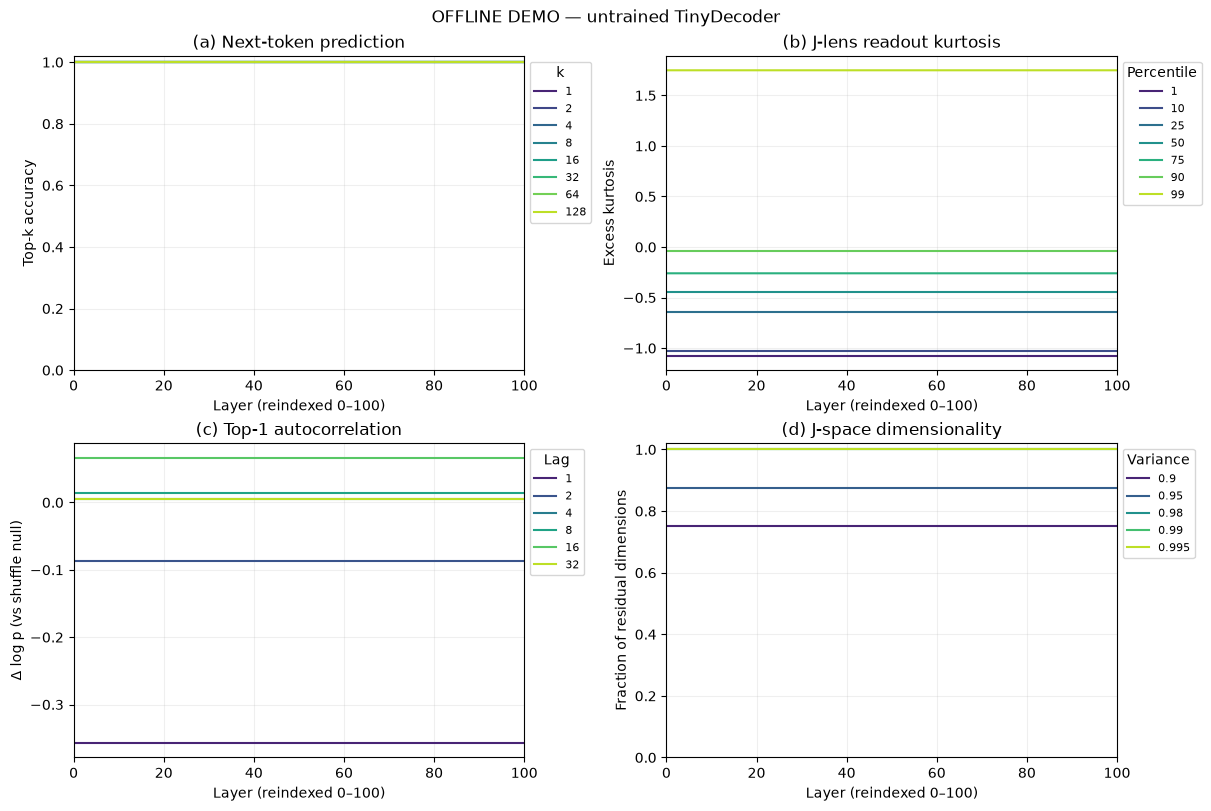

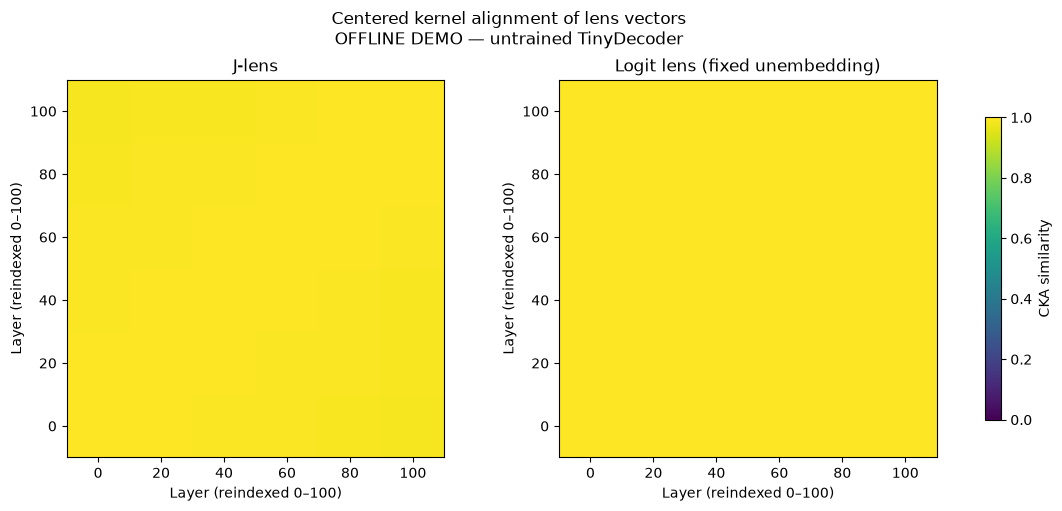

In [8]:
from jlens.workspace_plotting import (
    logit_lens_geometry,
    plot_cka_comparison,
    save_workspace_figure,
)

# Reuse the four diagnostic panels, replacing the standalone J-lens heatmap.
single_cka, fig28 = plot_workspace_layers(
    geometry, readouts, n_layers=model.n_layers, title=label,
)
plt.close(single_cka)
fig27 = plot_cka_comparison(geometry, n_layers=model.n_layers, title=label)
logit_geometry = logit_lens_geometry(geometry, final_layer=model.n_layers - 1)
np.save(RESULT_DIR / "logit_lens_cka.npy", logit_geometry.cka)
logit_geometry.dimensions.to_csv(RESULT_DIR / "logit_lens_dimensions.csv", index=False)

exports = []
for name, figure in (("figure27_cka", fig27), ("figure28_layer_diagnostics", fig28)):
    paths = save_workspace_figure(figure, RESULT_DIR / name)
    exports.append({"figure": name, **{kind: str(path) if path else "skipped (see warning)"
                                      for kind, path in paths.items()}})
display(pd.DataFrame(exports))
plt.show()

In [9]:
summary = (
    readouts["accuracy"].query("k == 1")[["layer", "accuracy", "n_tokens"]]
    .rename(columns={"accuracy": "top1_agreement"})
    .merge(readouts["kurtosis"].query("percentile == 50")
           [["layer", "excess_kurtosis", "n_valid"]], on="layer")
    .merge(readouts["autocorrelation"].query("lag == 1")
           [["layer", "delta_log_p", "n_pairs"]], on="layer")
    .merge(geometry.dimensions.query("variance == 0.99")
           [["layer", "dimension_fraction"]], on="layer")
)
display(summary.round(4))
print("Figure and table directory:", RESULT_DIR)
print("Demo results only." if RUN_MODE == "demo" else "Measured model: " + runtime["model_id"])

,layer,top1_agreement,n_tokens,excess_kurtosis,n_valid,delta_log_p,n_pairs,dimension_fraction
0,0,1.0,9334,-0.4467,9334,-0.3574,9191,1.0
1,1,1.0,9334,-0.4467,9334,-0.3574,9191,1.0
2,2,1.0,9334,-0.4467,9334,-0.3574,9191,1.0
3,3,1.0,9334,-0.4467,9334,-0.3574,9191,1.0
4,4,1.0,9334,-0.4467,9334,-0.3574,9191,1.0
5,5,1.0,9334,-0.4467,9334,-0.3574,9191,1.0


Figure and table directory: /home/kitlix/projects/jacobian-lens-gpt2/runs/workspace_layers/measurements/eeccf13f05efaed3
Demo results only.


## Conclusions

The logit-lens vector CKA control is uniform by construction because its unembedding vectors do not change across layers. It does not imply that logit-lens activations or token readouts stay constant.

The executed demo shows that the notebook produces both requested figure types, with final-layer prediction agreement equal to one and unit self-similarity for nondegenerate CKA. The tiny decoder is untrained and nearly linear: its patterns should not be interpreted as evidence for sensory, workspace, or motor regions.

For a trained-model run, examine whether broad CKA blocks coincide with changes in all four diagnostics. Agreement with a model's output does not measure task correctness, and a CKA block alone does not identify a functional workspace. Report the model/revision, lens provenance, actual fitting corpus, dtype, sequence limit, dimension batch size, evaluation corpus, and seed from the saved manifests. Interpret missing autocorrelation points using the pair-count table. Repeat with more fitting data and held-out natural text before making claims about layer boundaries.